In [1]:
# ============================================================
# CONSTRAINED vs UNCONSTRAINED COMPARISON NOTEBOOK
# ML-Based Predictive Irrigation System for Paddy Cultivation
# Cell 0.1 - Library Imports
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import joblib

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

RANDOM_STATE = 42
N_TRIALS_TREE = 80

print("=" * 70)
print("CONSTRAINED vs UNCONSTRAINED COMPARISON NOTEBOOK")
print("ML-Based Predictive Irrigation System for Paddy Cultivation")
print("=" * 70)
print("\nAll libraries imported successfully.")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


CONSTRAINED vs UNCONSTRAINED COMPARISON NOTEBOOK
ML-Based Predictive Irrigation System for Paddy Cultivation

All libraries imported successfully.
Timestamp: 2026-03-04 11:04:59


In [2]:
# ============================================================
# Cell 0.2 - Load Dataset
# ============================================================

dataset_filename = './Data/paddy_CWR_dataset_20260302_182512.csv'

try:
    df = pd.read_csv(dataset_filename)
    print(f"Dataset loaded: {dataset_filename}")
    print(f"Shape: {df.shape}  |  Features: {df.shape[1] - 1}  |  Samples: {df.shape[0]}")

    missing = df.isnull().sum()
    if missing.sum() == 0:
        print("No missing values detected.")
    else:
        print(f"Missing values:\n{missing[missing > 0]}")

    print("\nCWR Distribution:")
    print(f"  Min:    {df['CWR_mm'].min():.2f} mm")
    print(f"  Max:    {df['CWR_mm'].max():.2f} mm")
    print(f"  Mean:   {df['CWR_mm'].mean():.2f} mm")
    print(f"  Median: {df['CWR_mm'].median():.2f} mm")
    print(f"  Std:    {df['CWR_mm'].std():.2f} mm")

    display(df.head())
    display(df.describe())

except FileNotFoundError:
    print(f"ERROR: File '{dataset_filename}' not found.")
    print("Update 'dataset_filename' with the correct path.")


Dataset loaded: ./Data/paddy_CWR_dataset_20260302_182512.csv
Shape: (2000, 7)  |  Features: 6  |  Samples: 2000
No missing values detected.

CWR Distribution:
  Min:    0.00 mm
  Max:    199.98 mm
  Mean:   31.16 mm
  Median: 10.67 mm
  Std:    46.86 mm


,Water_Depth_cm,Soil_Moisture_%,Tank_Level_%,ET_mm_day,Rainfall_Predicted_mm,Crop_Stage,CWR_mm
0,0.00,84.2,53.9,6.31,14.88,5,0.0
1,15.81,93.3,72.8,5.49,16.57,1,0.0
2,11.60,99.3,62.2,9.68,0.00,4,53.7
3,3.90,97.2,16.6,4.41,9.13,3,0.0
4,12.65,95.3,47.1,9.79,19.34,4,0.0


,Water_Depth_cm,Soil_Moisture_%,Tank_Level_%,ET_mm_day,Rainfall_Predicted_mm,Crop_Stage,CWR_mm
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,5.433135,88.349400,57.222250,6.666695,3.306170,3.000000,31.155690
std,6.130906,12.463527,25.071412,1.643597,4.949343,1.414567,46.856673
min,0.000000,45.100000,15.100000,4.010000,0.000000,1.000000,0.000000
25%,0.120000,86.975000,34.700000,5.470000,0.000000,2.000000,4.035000
50%,3.020000,92.800000,57.200000,6.230000,0.055000,3.000000,10.670000
75%,11.072500,96.200000,79.100000,7.375000,5.000000,4.000000,36.885000
max,19.950000,100.000000,100.000000,10.000000,19.970000,5.000000,199.980000


In [3]:
# ============================================================
# Cell 0.3 - Feature/Target Split and Train/Val/Test Split
# Split: 70% Train | 15% Validation | 15% Test
# Stratified by Crop_Stage
# ============================================================

feature_columns = ['Water_Depth_cm', 'Soil_Moisture_%', 'Tank_Level_%',
                   'ET_mm_day', 'Rainfall_Predicted_mm', 'Crop_Stage']
target_column = 'CWR_mm'

X = df[feature_columns].copy()
y = df[target_column].copy()

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=df['Crop_Stage']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,  # 0.176 * 0.85 ≈ 0.15 of total
    random_state=RANDOM_STATE,
    stratify=X_temp['Crop_Stage']
)

print("=" * 70)
print("DATA SPLIT SUMMARY")
print("=" * 70)
print(f"Training set:    {len(X_train):4d} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set:  {len(X_val):4d} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set:        {len(X_test):4d} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"Total:           {len(X):4d} samples")

print("\nCrop Stage Distribution:")
print(f"{'Stage':<10} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 38)
for stage in sorted(df['Crop_Stage'].unique()):
    train_count = (X_train['Crop_Stage'] == stage).sum()
    val_count   = (X_val['Crop_Stage']   == stage).sum()
    test_count  = (X_test['Crop_Stage']  == stage).sum()
    print(f"Stage {stage}   {train_count:>8} {val_count:>8} {test_count:>8}")

print("\nData preparation complete.")


DATA SPLIT SUMMARY
Training set:    1400 samples (70.0%)
Validation set:   300 samples (15.0%)
Test set:         300 samples (15.0%)
Total:           2000 samples

Crop Stage Distribution:
Stage         Train      Val     Test
--------------------------------------
Stage 1        280       60       60
Stage 2        280       60       60
Stage 3        280       60       60
Stage 4        280       60       60
Stage 5        280       60       60

Data preparation complete.


In [32]:
# ============================================================
# Cell 1.1 - Optuna Tuning: XGBoost
# Trains TWO models with a SINGLE Optuna study:
#   - Constrained   : FAO-56 monotone constraints applied
#   - Unconstrained : Identical hyperparameters, no constraints
# Constraint order matches feature_columns:
#   [Water_Depth_cm(-1), Soil_Moisture_%(-1), Tank_Level_%(0),
#    ET_mm_day(+1), Rainfall_Predicted_mm(-1), Crop_Stage(0)]
# ============================================================

MONOTONE_CONSTRAINTS_XGB = (-1, -1, 0, 1, -1, 0)

def objective_xgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0.0, 5.0),
    }
    model = XGBRegressor(
        **params,
        monotone_constraints=MONOTONE_CONSTRAINTS_XGB,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )
    model.fit(X_train, y_train)
    return mean_absolute_error(y_val, model.predict(X_val))

print("-" * 60)
print("Optimizing XGBoost with Optuna TPE...")
print("-" * 60)

start = time.time()
study_xgb = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS_TREE, show_progress_bar=True, timeout=600)
xgb_time = time.time() - start

best_params_xgb = study_xgb.best_params

# --- Constrained ---
xgb_model_c = XGBRegressor(
    **best_params_xgb,
    monotone_constraints=MONOTONE_CONSTRAINTS_XGB,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)
xgb_model_c.fit(X_train, y_train)

# --- Unconstrained (same hyperparameters) ---
xgb_model_nc = XGBRegressor(
    **best_params_xgb,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)
xgb_model_nc.fit(X_train, y_train)

xgb_c_mae  = mean_absolute_error(y_val, xgb_model_c.predict(X_val))
xgb_nc_mae = mean_absolute_error(y_val, xgb_model_nc.predict(X_val))

print(f"\nXGBoost Tuning Complete  |  Time: {xgb_time:.1f}s")
print(f"  Constrained   Val MAE: {xgb_c_mae:.4f} mm")
print(f"  Unconstrained Val MAE: {xgb_nc_mae:.4f} mm")
print(f"  Best Params: {best_params_xgb}")


------------------------------------------------------------
Optimizing XGBoost with Optuna TPE...
------------------------------------------------------------


  0%|          | 0/80 [00:00<?, ?it/s]


XGBoost Tuning Complete  |  Time: 20.6s
  Constrained   Val MAE: 6.4693 mm
  Unconstrained Val MAE: 8.6125 mm
  Best Params: {'n_estimators': 435, 'max_depth': 10, 'learning_rate': 0.012015689627816628, 'subsample': 0.7748313941366849, 'colsample_bytree': 0.9423970629075488, 'reg_alpha': 7.760963020680746e-07, 'reg_lambda': 2.5123704243448226, 'min_child_weight': 3, 'gamma': 0.8468055080712458}


In [5]:
# ============================================================
# Cell 1.2 - Optuna Tuning: LightGBM
# Constraint order matches feature_columns:
#   [Water_Depth_cm(-1), Soil_Moisture_%(-1), Tank_Level_%(0),
#    ET_mm_day(+1), Rainfall_Predicted_mm(-1), Crop_Stage(0)]
# ============================================================

MONOTONE_CONSTRAINTS_LGB = [-1, -1, 0, 1, -1, 0]

def objective_lgb(trial):
    params = {
        'n_estimators':       trial.suggest_int('n_estimators', 100, 500),
        'max_depth':          trial.suggest_int('max_depth', 3, 15),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':          trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'num_leaves':         trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples':  trial.suggest_int('min_child_samples', 5, 50),
    }
    model = LGBMRegressor(
        **params,
        monotone_constraints=MONOTONE_CONSTRAINTS_LGB,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    )
    model.fit(X_train, y_train)
    return mean_absolute_error(y_val, model.predict(X_val))

print("-" * 60)
print("Optimizing LightGBM with Optuna TPE...")
print("-" * 60)

start = time.time()
study_lgb = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS_TREE, show_progress_bar=True, timeout=600)
lgb_time = time.time() - start

best_params_lgb = study_lgb.best_params

# --- Constrained ---
lgb_model_c = LGBMRegressor(
    **best_params_lgb,
    monotone_constraints=MONOTONE_CONSTRAINTS_LGB,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)
lgb_model_c.fit(X_train, y_train)

# --- Unconstrained (same hyperparameters) ---
lgb_model_nc = LGBMRegressor(
    **best_params_lgb,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)
lgb_model_nc.fit(X_train, y_train)

lgb_c_mae  = mean_absolute_error(y_val, lgb_model_c.predict(X_val))
lgb_nc_mae = mean_absolute_error(y_val, lgb_model_nc.predict(X_val))

print(f"\nLightGBM Tuning Complete  |  Time: {lgb_time:.1f}s")
print(f"  Constrained   Val MAE: {lgb_c_mae:.4f} mm")
print(f"  Unconstrained Val MAE: {lgb_nc_mae:.4f} mm")
print(f"  Best Params: {best_params_lgb}")


------------------------------------------------------------
Optimizing LightGBM with Optuna TPE...
------------------------------------------------------------


  0%|          | 0/80 [00:00<?, ?it/s]


LightGBM Tuning Complete  |  Time: 36.5s
  Constrained   Val MAE: 5.7512 mm
  Unconstrained Val MAE: 3.6317 mm
  Best Params: {'n_estimators': 228, 'max_depth': 15, 'learning_rate': 0.020604341214793317, 'subsample': 0.8513879247841697, 'colsample_bytree': 0.9230262891170002, 'reg_alpha': 0.2451212736606458, 'reg_lambda': 3.5757602054119436e-07, 'num_leaves': 62, 'min_child_samples': 6}


In [6]:
# ============================================================
# Cell 1.3 - Optuna Tuning: CatBoost
# CatBoost accepts constraints as a feature-name dict
# ============================================================

MONOTONE_CONSTRAINTS_CAT = {
    'ET_mm_day':             1,
    'Rainfall_Predicted_mm': -1,
    'Water_Depth_cm':        -1,
    'Soil_Moisture_%':       -1,
}

def objective_cat(trial):
    params = {
        'iterations':         trial.suggest_int('iterations', 100, 500),
        'depth':              trial.suggest_int('depth', 3, 10),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg':        trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'subsample':          trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bylevel':  trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'min_data_in_leaf':   trial.suggest_int('min_data_in_leaf', 1, 50),
    }
    model = CatBoostRegressor(
        **params,
        monotone_constraints=MONOTONE_CONSTRAINTS_CAT,
        random_seed=RANDOM_STATE,
        verbose=0
    )
    model.fit(X_train, y_train)
    return mean_absolute_error(y_val, model.predict(X_val))

print("-" * 60)
print("Optimizing CatBoost with Optuna TPE...")
print("-" * 60)

start = time.time()
study_cat = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_cat.optimize(objective_cat, n_trials=N_TRIALS_TREE, show_progress_bar=True, timeout=600)
cat_time = time.time() - start

best_params_cat = study_cat.best_params

# --- Constrained ---
cat_model_c = CatBoostRegressor(
    **best_params_cat,
    monotone_constraints=MONOTONE_CONSTRAINTS_CAT,
    random_seed=RANDOM_STATE,
    verbose=0
)
cat_model_c.fit(X_train, y_train)

# --- Unconstrained (same hyperparameters) ---
cat_model_nc = CatBoostRegressor(
    **best_params_cat,
    random_seed=RANDOM_STATE,
    verbose=0
)
cat_model_nc.fit(X_train, y_train)

cat_c_mae  = mean_absolute_error(y_val, cat_model_c.predict(X_val))
cat_nc_mae = mean_absolute_error(y_val, cat_model_nc.predict(X_val))

print(f"\nCatBoost Tuning Complete  |  Time: {cat_time:.1f}s")
print(f"  Constrained   Val MAE: {cat_c_mae:.4f} mm")
print(f"  Unconstrained Val MAE: {cat_nc_mae:.4f} mm")
print(f"  Best Params: {best_params_cat}")


------------------------------------------------------------
Optimizing CatBoost with Optuna TPE...
------------------------------------------------------------


  0%|          | 0/80 [00:00<?, ?it/s]


CatBoost Tuning Complete  |  Time: 264.6s
  Constrained   Val MAE: 2.2916 mm
  Unconstrained Val MAE: 3.2801 mm
  Best Params: {'iterations': 481, 'depth': 8, 'learning_rate': 0.29462993831441286, 'l2_leaf_reg': 0.015113055679893283, 'subsample': 0.7746470991995673, 'colsample_bylevel': 0.9081487478535625, 'min_data_in_leaf': 10}


In [34]:
# ============================================================
# Cell 2.1 - Performance Metrics: Constrained vs Unconstrained
# Evaluated on Validation and Test sets
# ============================================================

def compute_metrics(model, X, y):
    preds = model.predict(X)
    return {
        'MAE':   mean_absolute_error(y, preds),
        'RMSE':  np.sqrt(mean_squared_error(y, preds)),
        'R2':    r2_score(y, preds),
        'preds': preds
    }

models_info = {
    'XGBoost':  {'constrained': xgb_model_c, 'unconstrained': xgb_model_nc},
    'LightGBM': {'constrained': lgb_model_c, 'unconstrained': lgb_model_nc},
    'CatBoost': {'constrained': cat_model_c, 'unconstrained': cat_model_nc},
}

results = {}
for name, pair in models_info.items():
    for variant, model in pair.items():
        key = f"{name} ({variant})"
        val_m  = compute_metrics(model, X_val,  y_val)
        test_m = compute_metrics(model, X_test, y_test)
        results[key] = {
            'Model':     name,
            'Variant':   variant.capitalize(),
            'Val MAE':   round(val_m['MAE'],   4),
            'Val RMSE':  round(val_m['RMSE'],  4),
            'Val R²':    round(val_m['R2'],    4),
            'Test MAE':  round(test_m['MAE'],  4),
            'Test RMSE': round(test_m['RMSE'], 4),
            'Test R²':   round(test_m['R2'],   4),
        }

results_df = pd.DataFrame(results).T.reset_index(drop=True)

print("=" * 70)
print("CONSTRAINED vs UNCONSTRAINED — FULL METRICS TABLE")
print("=" * 70)
display(results_df)

# Delta table
print("\n" + "=" * 70)
print("CONSTRAINT IMPACT (Constrained − Unconstrained) — Test Set")
print("Negative ΔMAE / ΔRMSE  → constraints IMPROVED accuracy")
print("Positive ΔR²           → constraints IMPROVED fit")
print("=" * 70)

delta_rows = []
for name in models_info.keys():
    c  = results[f"{name} (constrained)"]
    nc = results[f"{name} (unconstrained)"]
    delta_rows.append({
        'Model': name,
        'ΔMAE':  round(c['Test MAE']  - nc['Test MAE'],  4),
        'ΔRMSE': round(c['Test RMSE'] - nc['Test RMSE'], 4),
        'ΔR²':   round(c['Test R²']   - nc['Test R²'],   4),
    })

delta_df = pd.DataFrame(delta_rows)
display(delta_df)

CONSTRAINED vs UNCONSTRAINED — FULL METRICS TABLE


,Model,Variant,Val MAE,Val RMSE,Val R²,Test MAE,Test RMSE,Test R²
0,XGBoost,Constrained,6.4693,11.1335,0.9325,6.9481,12.0183,0.9345
1,XGBoost,Unconstrained,8.6125,13.4011,0.9168,8.3834,14.0436,0.9142
2,LightGBM,Constrained,5.7512,10.0506,0.945,6.0095,12.2339,0.9322
3,LightGBM,Unconstrained,3.6317,9.4744,0.9511,3.3398,8.0265,0.9708
4,CatBoost,Constrained,2.2916,4.1185,0.9908,2.3753,4.1261,0.9923
5,CatBoost,Unconstrained,3.2801,7.6401,0.9682,3.24,5.8523,0.9845



CONSTRAINT IMPACT (Constrained − Unconstrained) — Test Set
Negative ΔMAE / ΔRMSE  → constraints IMPROVED accuracy
Positive ΔR²           → constraints IMPROVED fit


,Model,ΔMAE,ΔRMSE,ΔR²
0,XGBoost,-1.4353,-2.0253,0.0203
1,LightGBM,2.6697,4.2074,-0.0386
2,CatBoost,-0.8647,-1.7262,0.0078


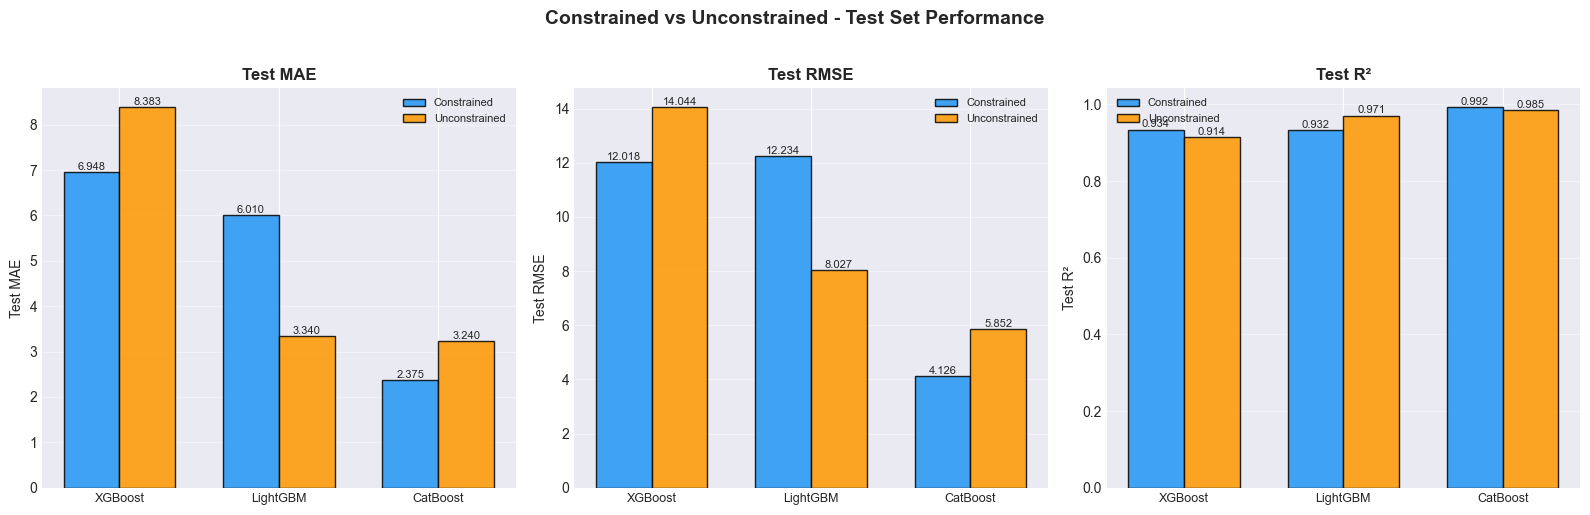

Saved: ./Visualisation_MCvsNMC/constraint_comparison_metrics.png


In [31]:
# ============================================================
# Cell 2.2 - Grouped Bar Charts: Constrained vs Unconstrained
# ============================================================

import os
os.makedirs('./Visualisation_MCvsNMC', exist_ok=True)

metrics     = ['Test MAE', 'Test RMSE', 'Test R²']
model_names = list(models_info.keys())
x           = np.arange(len(model_names))
width       = 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Constrained vs Unconstrained - Test Set Performance',
             fontsize=14, fontweight='bold', y=1.02)

colors = {'constrained': '#2196F3', 'unconstrained': '#FF9800'}

for ax, metric in zip(axes, metrics):
    vals_c  = [results[f"{m} (constrained)"][metric]   for m in model_names]
    vals_nc = [results[f"{m} (unconstrained)"][metric] for m in model_names]

    bars_c  = ax.bar(x - width/2, vals_c,  width, label='Constrained',
                     color=colors['constrained'],   alpha=0.85, edgecolor='black')
    bars_nc = ax.bar(x + width/2, vals_nc, width, label='Unconstrained',
                     color=colors['unconstrained'], alpha=0.85, edgecolor='black')

    for bar in list(bars_c) + list(bars_nc):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.002,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=9)
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('./Visualisation_MCvsNMC/constraint_comparison_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ./Visualisation_MCvsNMC/constraint_comparison_metrics.png")


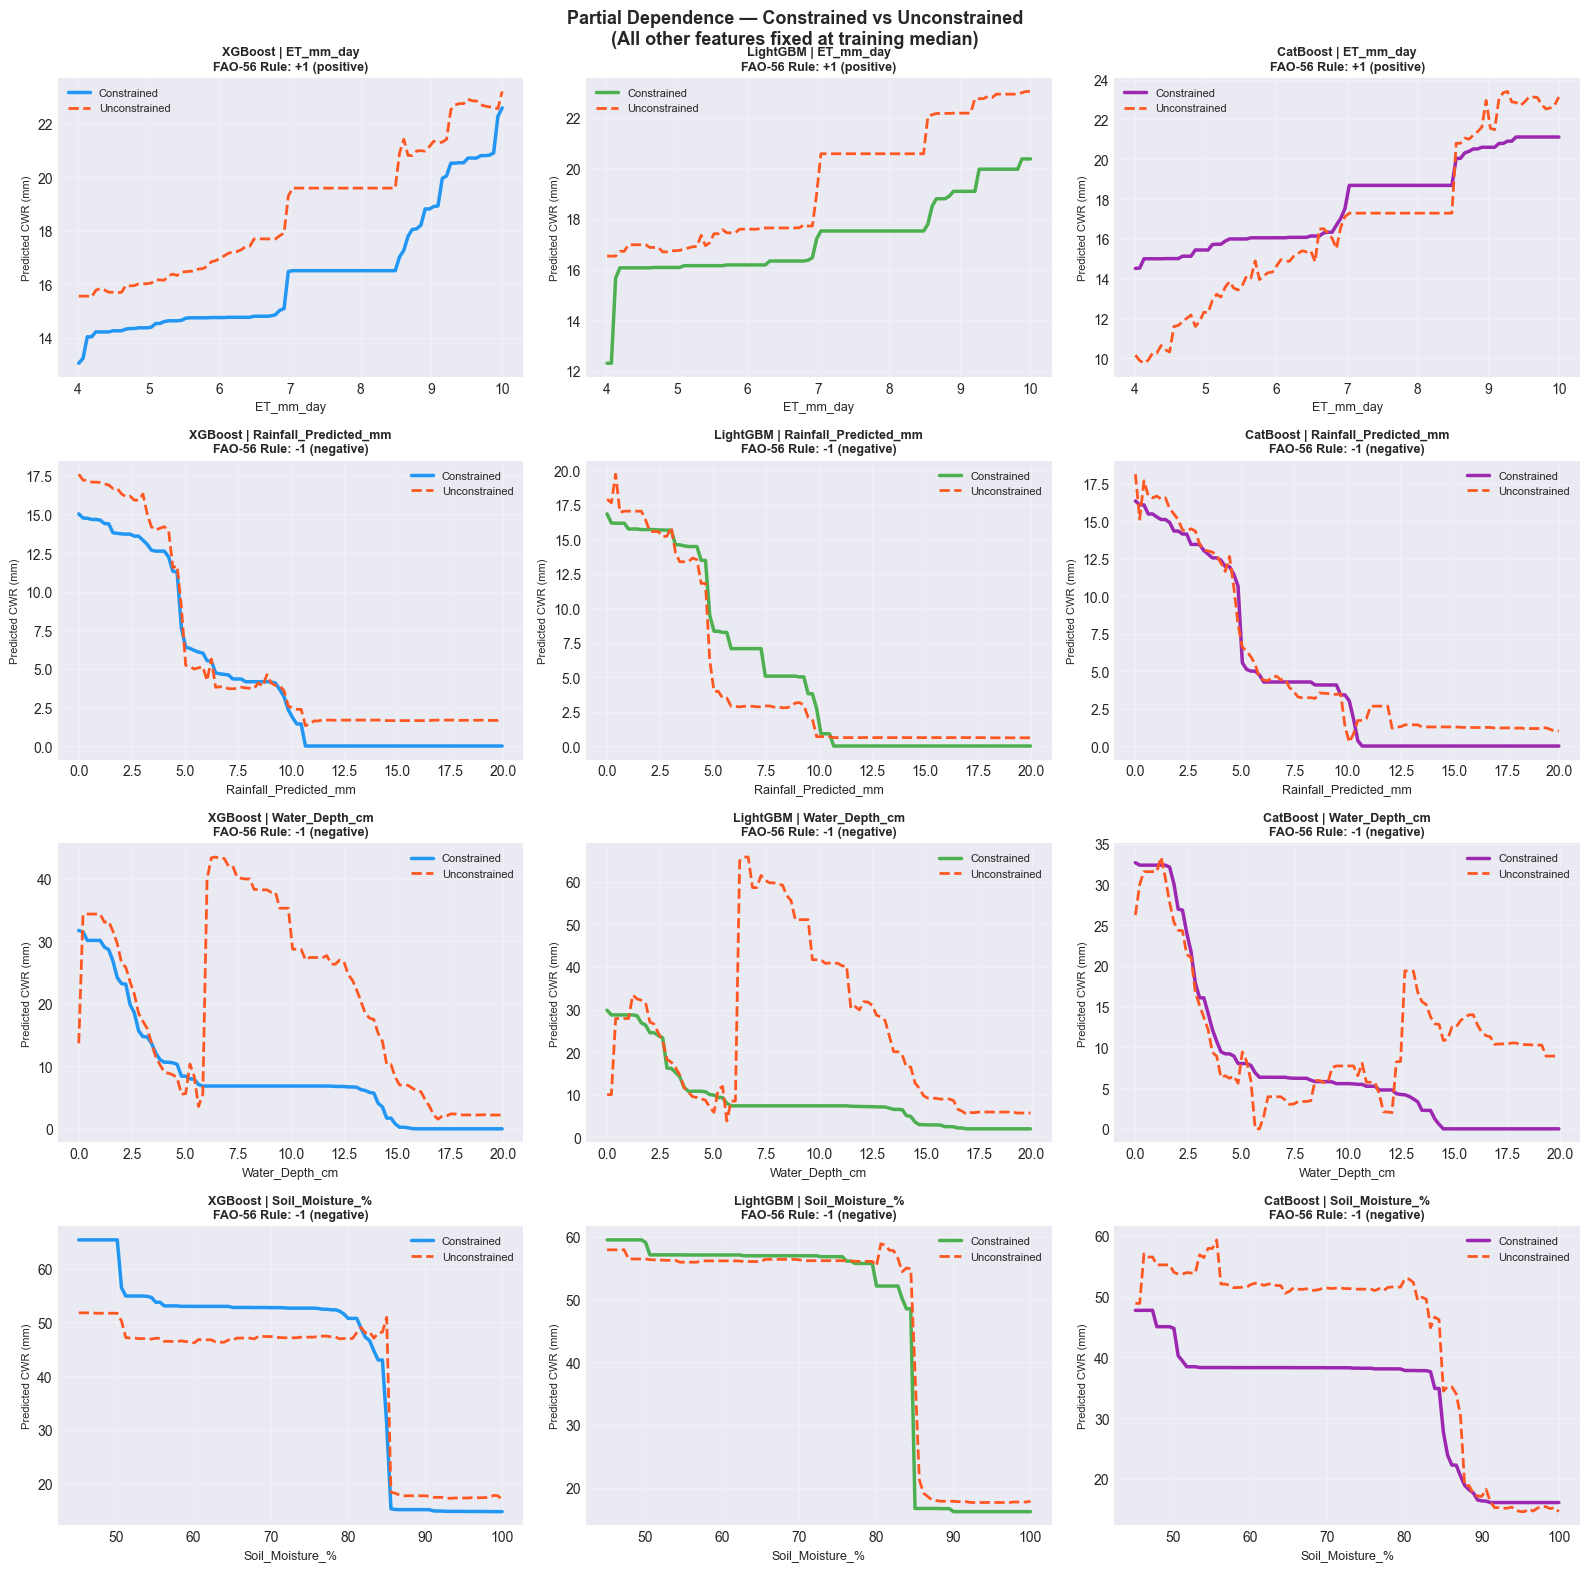

Saved: ./Visualisation/partial_dependence_constraint_check.png


In [26]:
# ============================================================
# Cell 2.3 - Partial Dependence Plots
# Verifies that constrained models respect FAO-56 directions
# at inference. Each constrained feature is swept across its
# observed range while all other features are held at median.
# ============================================================

constrained_features = {
    'ET_mm_day':             {'direction': '+1 (positive)', 'range': (X['ET_mm_day'].min(),            X['ET_mm_day'].max())},
    'Rainfall_Predicted_mm': {'direction': '-1 (negative)', 'range': (X['Rainfall_Predicted_mm'].min(), X['Rainfall_Predicted_mm'].max())},
    'Water_Depth_cm':        {'direction': '-1 (negative)', 'range': (X['Water_Depth_cm'].min(),        X['Water_Depth_cm'].max())},
    'Soil_Moisture_%':       {'direction': '-1 (negative)', 'range': (X['Soil_Moisture_%'].min(),       X['Soil_Moisture_%'].max())},
}

baseline = X_train.median().to_dict()

model_triples = [
    ('XGBoost',  xgb_model_c, xgb_model_nc,  '#2196F3'),
    ('LightGBM', lgb_model_c, lgb_model_nc,  '#4CAF50'),
    ('CatBoost', cat_model_c, cat_model_nc,  '#9C27B0'),
]

n_features = len(constrained_features)
fig, axes = plt.subplots(n_features, 3, figsize=(16, 4 * n_features))
fig.suptitle('Partial Dependence - Constrained vs Unconstrained\n'
             '(All other features fixed at training median)',
             fontsize=13, fontweight='bold')

for row_idx, (feat, info) in enumerate(constrained_features.items()):
    feat_range = np.linspace(info['range'][0], info['range'][1], 100)

    for col_idx, (model_name, model_c, model_nc, color) in enumerate(model_triples):
        ax = axes[row_idx, col_idx]
        preds_c, preds_nc = [], []

        for val in feat_range:
            row_data = baseline.copy()
            row_data[feat] = val
            x_input = pd.DataFrame([row_data])[feature_columns]
            preds_c.append(max(0.0, model_c.predict(x_input)[0])) 
            preds_nc.append(max(0.0, model_nc.predict(x_input)[0]))

        ax.plot(feat_range, preds_c,  color=color,     lw=2.5,
                label='Constrained',   linestyle='-')
        ax.plot(feat_range, preds_nc, color='#FF5722', lw=2.0,
                label='Unconstrained', linestyle='--')

        ax.set_xlabel(feat, fontsize=9)
        ax.set_ylabel('Predicted CWR (mm)', fontsize=8)
        ax.set_title(f'{model_name} | {feat}\nFAO-56 Rule: {info["direction"]}',
                     fontsize=9, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./Visualisation_MCvsNMC/partial_dependence_constraint_check.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ./Visualisation_MCvsNMC/partial_dependence_constraint_check.png")


In [25]:
# ============================================================
# Cell 2.4 - Monotonicity Violation Audit
# Sweeps each constrained feature across its range per test
# sample and counts direction violations.
# Constrained models MUST score 0 violations.
# ============================================================

def count_violations(model, X_data, feature, direction, n_steps=50):
    feat_min   = X_data[feature].min()
    feat_max   = X_data[feature].max()
    sweep      = np.linspace(feat_min, feat_max, n_steps)
    violations = 0
    total_pairs = 0

    for _, row in X_data.iterrows():
        preds = []
        for val in sweep:
            r = row.copy()
            r[feature] = val
            preds.append(model.predict(pd.DataFrame([r])[feature_columns])[0])

        for i in range(len(preds) - 1):
            total_pairs += 1
            if direction ==  1 and preds[i+1] < preds[i] - 1e-6:
                violations += 1
            elif direction == -1 and preds[i+1] > preds[i] + 1e-6:
                violations += 1

    pct = (violations / total_pairs * 100) if total_pairs > 0 else 0.0
    return violations, total_pairs, round(pct, 2)

constraint_map = {
    'ET_mm_day':              1,
    'Rainfall_Predicted_mm': -1,
    'Water_Depth_cm':        -1,
    'Soil_Moisture_%':       -1,
}

# Sample test set to keep runtime reasonable (increase n for fuller audit)
X_audit = X_test.sample(n=min(50, len(X_test)), random_state=RANDOM_STATE)

print("=" * 100)
print("MONOTONICITY VIOLATION AUDIT - Test Set Sample (n=50)")
print("=" * 100)
print(f"{'Model':<15} {'Feature':<25} {'Variant':<16} {'Violations':>12} {'Total Pairs':>13} {'Violation %':>12}")
print("-" * 100)

audit_rows = []
for name, model_c, model_nc, _ in model_triples:
    for feat, direction in constraint_map.items():
        for variant_label, model in [('Constrained', model_c), ('Unconstrained', model_nc)]:
            v, t, pct = count_violations(model, X_audit, feat, direction)
            print(f"{name:<15} {feat:<25} {variant_label:<16} {v:>12} {t:>13} {pct:>11.2f}%")
            audit_rows.append({
                'Model': name, 'Feature': feat, 'Variant': variant_label,
                'Violations': v, 'Total Pairs': t, 'Violation %': pct
            })

audit_df = pd.DataFrame(audit_rows)

print("\n" + "=" * 60)
print("SUMMARY - Total Violations per Model / Variant")
print("=" * 60)
summary = audit_df.groupby(['Model', 'Variant'])['Violations'].sum().unstack()
display(summary)

audit_df.to_csv('./Visualisation_MCvsNMC/monotonicity_audit.csv', index=False)
print("\nSaved: ./Visualisation_MCvsNMC/monotonicity_audit.csv")


MONOTONICITY VIOLATION AUDIT — Test Set Sample (n=50)
Model           Feature                   Variant            Violations   Total Pairs  Violation %
----------------------------------------------------------------------------------------------------
XGBoost         ET_mm_day                 Constrained                 0          2450        0.00%
XGBoost         ET_mm_day                 Unconstrained             677          2450       27.63%
XGBoost         Rainfall_Predicted_mm     Constrained                 0          2450        0.00%
XGBoost         Rainfall_Predicted_mm     Unconstrained             738          2450       30.12%
XGBoost         Water_Depth_cm            Constrained                 0          2450        0.00%
XGBoost         Water_Depth_cm            Unconstrained             459          2450       18.73%
XGBoost         Soil_Moisture_%           Constrained                 0          2450        0.00%
XGBoost         Soil_Moisture_%           Unconstrain

Variant,Constrained,Unconstrained
Model,,
CatBoost,0,3502
LightGBM,0,1442
XGBoost,0,2637



Saved: ./Visualisation/monotonicity_audit.csv
